# 文件: chart_21_1.py

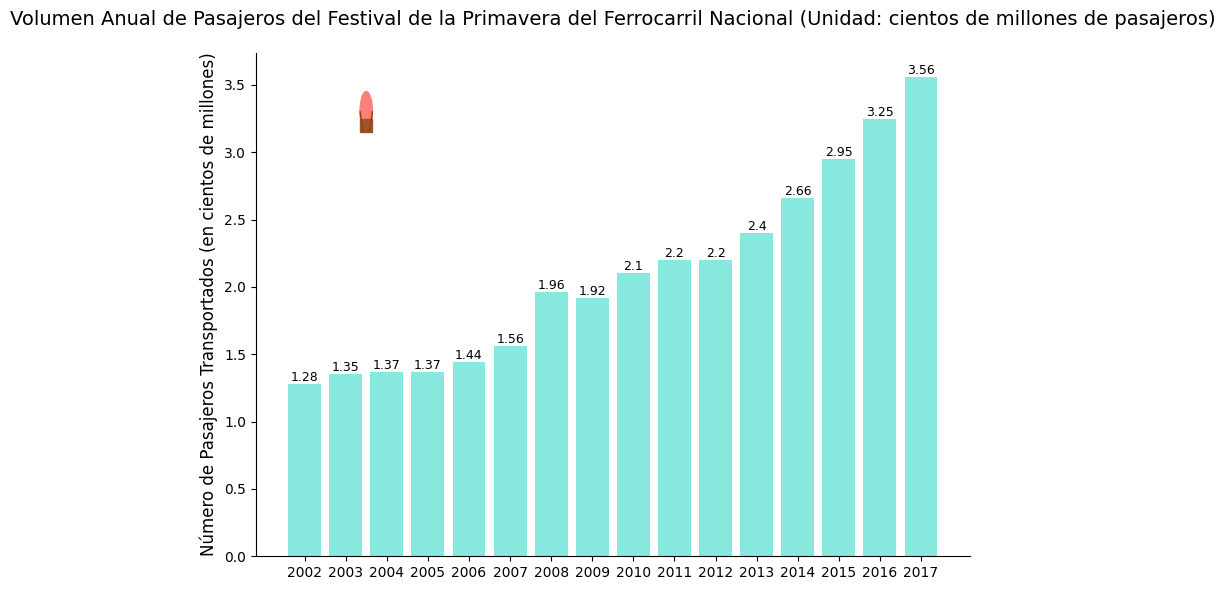

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Datos de años
years = np.arange(2002, 2018)
# Datos de volumen de pasajeros correspondientes a cada año (aproximadamente cercanos a los datos originales)
passenger_volumes = [1.28, 1.35, 1.37, 1.37, 1.44, 1.56, 
                     1.96, 1.92, 2.1, 2.2, 2.2, 2.4, 
                     2.66, 2.95, 3.25, 3.56]

# Crear una figura
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar un gráfico de barras, establecer el color para que sea cercano al esquema de color verde claro del gráfico original
bar_rects = ax.bar(years, passenger_volumes, color='#87E8DE')

# Establecer las marcas del eje x
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=10)

# Establecer la etiqueta del eje y
ax.set_ylabel('Número de Pasajeros Transportados (en cientos de millones)', fontsize=12)
# Establecer el título
ax.set_title('Volumen Anual de Pasajeros del Festival de la Primavera del Ferrocarril Nacional (Unidad: cientos de millones de pasajeros)', fontsize=14, pad=20)

# Ocultar los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Etiquetar los valores en las barras
for rect in bar_rects:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, f'{height}',
            ha='center', va='bottom', fontsize=9)

# Agregar algunos elementos decorativos, usar gráficos puros en lugar de imágenes
hot_air_balloon = patches.Circle((2003.5, 3.3), 0.15, color='#FF7E79')
ax.add_patch(hot_air_balloon)

# Dibujar la cesta y las cuerdas del globo aerostático
basket = patches.Rectangle((2003.35, 3.15), 0.3, 0.1, color='#A0522D')
ax.add_patch(basket)

# Dibujar las cuerdas
ax.plot([2003.35, 2003.425], [3.3, 3.15], color='#8B4513', linewidth=1)
ax.plot([2003.65, 2003.575], [3.3, 3.15], color='#8B4513', linewidth=1)

plt.tight_layout()
plt.show()

# 文件: chart_21_2.py

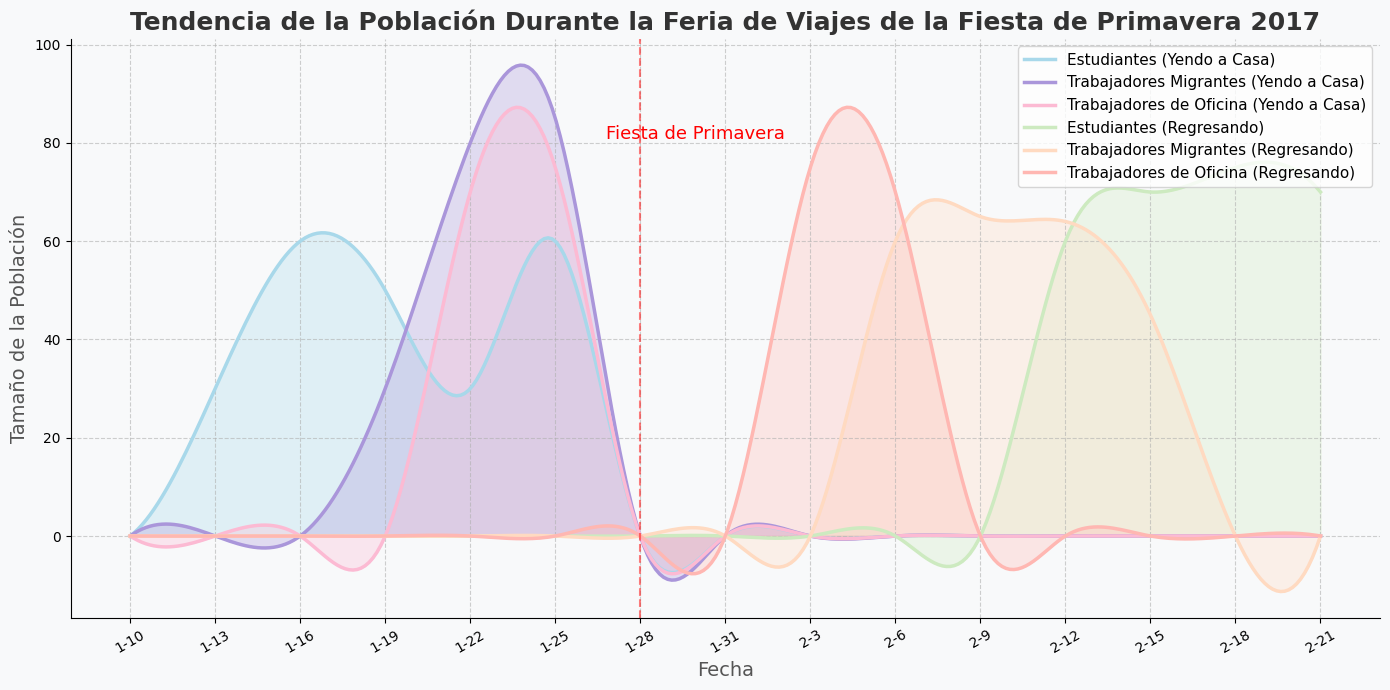

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Simular datos originales (fechas, tamaño de la población)
fechas = np.array(['1-10', '1-13', '1-16', '1-19', '1-22', '1-25', '1-28',
                  '1-31', '2-3', '2-6', '2-9', '2-12', '2-15', '2-18', '2-21'])

# Datos de estudiantes que se van a casa (picos el 1-19 y 1-25, mitad del pico el 1-22, 0 el 1-10 y 2-21)
estudiantes_van = np.array([0, 30, 60, 50, 30, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Datos de trabajadores migrantes que se van a casa (pico alrededor del 1-25)
trabajadores_migrantes_van = np.array([0, 0, 0, 30, 80, 85, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Datos de trabajadores de oficina que se van a casa (pico alrededor del 1-22)
trabajadores_oficina_van = np.array([0, 0, 0, 0, 70, 75, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Datos de regreso (distribución uniforme en febrero)
estudiantes_regresan = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 70, 75, 70])
trabajadores_migrantes_regresan = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 65, 64, 45, 0, 0])
trabajadores_oficina_regresan = np.array([0, 0, 0, 0, 0, 0, 0, 0, 75, 70, 0, 0, 0, 0, 0])

# 2. Crear un eje de tiempo uniformemente distribuido
x_uniforme = np.arange(len(fechas))  # Eje numérico uniformemente distribuido

# 3. Procesamiento de interpolación y suavizado
def suavizar_curva(y):
    x_nuevo = np.linspace(x_uniforme.min(), x_uniforme.max(), 300)
    spline = make_interp_spline(x_uniforme, y, k = 3)
    return x_nuevo, spline(x_nuevo)

# Proceso de suavizado
x_suave, estudiantes_van_suave = suavizar_curva(estudiantes_van)
_, trabajadores_migrantes_van_suave = suavizar_curva(trabajadores_migrantes_van)
_, trabajadores_oficina_van_suave = suavizar_curva(trabajadores_oficina_van)

_, estudiantes_regresan_suave = suavizar_curva(estudiantes_regresan)
_, trabajadores_migrantes_regresan_suave = suavizar_curva(trabajadores_migrantes_regresan)
_, trabajadores_oficina_regresan_suave = suavizar_curva(trabajadores_oficina_regresan)

# 4. Dibujar el gráfico de curvas
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

# Curva y relleno de la fase de ida
estudiantes_van_linea, = ax.plot(x_suave, estudiantes_van_suave, color='#A8D8EA', linewidth=2.5, label='Estudiantes (Yendo a Casa)')
ax.fill_between(x_suave, estudiantes_van_suave, color='#A8D8EA', alpha=0.3)  # Rellenar la curva de estudiantes que se van a casa

trabajadores_migrantes_van_linea, = ax.plot(x_suave, trabajadores_migrantes_van_suave, color='#AA96DA', linewidth=2.5, label='Trabajadores Migrantes (Yendo a Casa)')
ax.fill_between(x_suave, trabajadores_migrantes_van_suave, color='#AA96DA', alpha=0.3)  # Rellenar la curva de trabajadores migrantes que se van a casa

trabajadores_oficina_van_linea, = ax.plot(x_suave, trabajadores_oficina_van_suave, color='#FCBAD3', linewidth=2.5, label='Trabajadores de Oficina (Yendo a Casa)')
ax.fill_between(x_suave, trabajadores_oficina_van_suave, color='#FCBAD3', alpha=0.3)  # Rellenar la curva de trabajadores de oficina que se van a casa

# Curva y relleno de la fase de regreso
estudiantes_regresan_linea, = ax.plot(x_suave, estudiantes_regresan_suave, color='#CDEAC0', linewidth=2.5, label='Estudiantes (Regresando)')
ax.fill_between(x_suave, estudiantes_regresan_suave, color='#CDEAC0', alpha=0.3)  # Rellenar la curva de estudiantes que regresan

trabajadores_migrantes_regresan_linea, = ax.plot(x_suave, trabajadores_migrantes_regresan_suave, color='#FFDAC1', linewidth=2.5, label='Trabajadores Migrantes (Regresando)')
ax.fill_between(x_suave, trabajadores_migrantes_regresan_suave, color='#FFDAC1', alpha=0.3)  # Rellenar la curva de trabajadores migrantes que regresan

trabajadores_oficina_regresan_linea, = ax.plot(x_suave, trabajadores_oficina_regresan_suave, color='#FFB7B2', linewidth=2.5, label='Trabajadores de Oficina (Regresando)')
ax.fill_between(x_suave, trabajadores_oficina_regresan_suave, color='#FFB7B2', alpha=0.3)  # Rellenar la curva de trabajadores de oficina que regresan

# 5. Establecer las etiquetas de las marcas del eje x
plt.xticks(x_uniforme, fechas)
plt.xticks(rotation=30)

# 6. Agregar título, leyenda y decoración
ax.set_title('Tendencia de la Población Durante la Feria de Viajes de la Fiesta de Primavera 2017', fontsize=18, fontweight='bold', color='#333')
ax.set_xlabel('Fecha', fontsize=14, color='#555')
ax.set_ylabel('Tamaño de la Población', fontsize=14, color='#555')
ax.legend(loc='upper right', fontsize=11)

# 7. Agregar una línea divisoria (posición de la Fiesta de Primavera)
plt.axvline(x = 6.0, color='red', linestyle='--', alpha=0.5)
plt.text(5.6, max(estudiantes_van.max(), trabajadores_migrantes_van.max(), trabajadores_oficina_van.max()) * 0.95,
         'Fiesta de Primavera', fontsize=13, color='red')

# 8. Agregar líneas de cuadrícula
plt.grid(True, linestyle='--', alpha=0.6)

# 9. Ocultar los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 10. Mostrar el gráfico
plt.tight_layout()
plt.show()

# 文件: chart_21_3.py

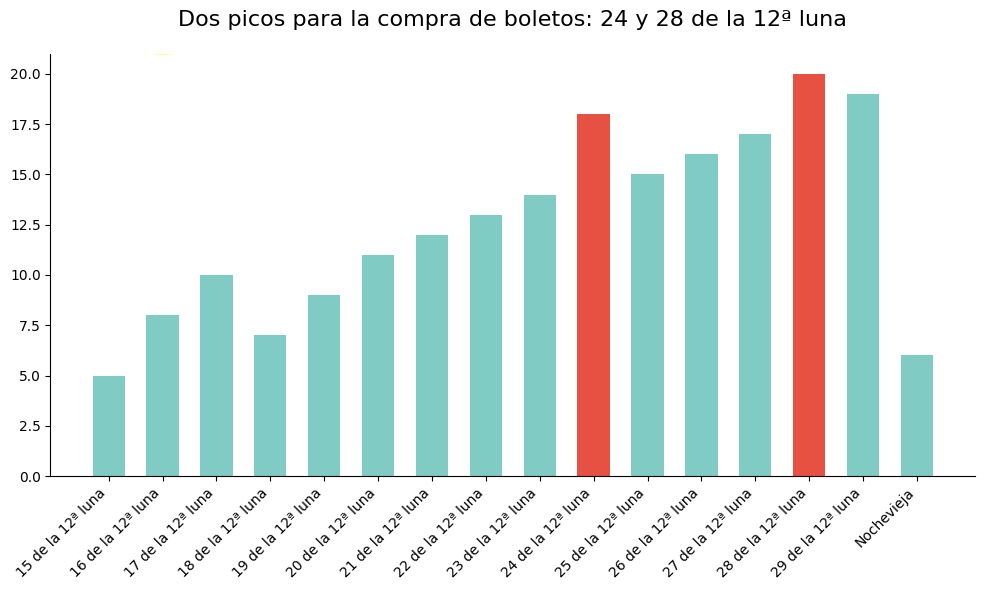

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Etiquetas de fechas
etiquetas = ["15 de la 12ª luna", "16 de la 12ª luna", "17 de la 12ª luna",
             "18 de la 12ª luna", "19 de la 12ª luna", "20 de la 12ª luna",
             "21 de la 12ª luna", "22 de la 12ª luna", "23 de la 12ª luna",
             "24 de la 12ª luna", "25 de la 12ª luna", "26 de la 12ª luna",
             "27 de la 12ª luna", "28 de la 12ª luna", "29 de la 12ª luna",
             "Nochevieja"]
# Datos simulados, generalmente mostrando una tendencia de picos, se pueden ajustar según la situación real
datos = [5, 8, 10, 7, 9, 11, 12, 13, 14, 18, 15, 16, 17, 20, 19, 6]
# Índices de las fechas pico (24 y 28 de la 12ª luna, correspondientes a los índices 9 y 13 en las etiquetas anteriores)
indices_pico = [9, 13]

x = np.arange(len(etiquetas))  # Posiciones del eje x
ancho = 0.6  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))  # Crear un lienzo y ejes
# Dibujar el gráfico de barras, la mayoría de las barras de un color, las barras pico de otro color
barras = []
for i in range(len(x)):
    if i in indices_pico:
        barra = ax.bar(x[i], datos[i], ancho, color='#e65142')  # Color pico, similar al rojo en el gráfico original
    else:
        barra = ax.bar(x[i], datos[i], ancho, color='#80cbc4')  # Color de las otras barras, similar al cian - verde en el gráfico original
    barras.append(barra)

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=45, ha='right')

# Establecer el título
ax.set_title('Dos picos para la compra de boletos: 24 y 28 de la 12ª luna', fontsize=16, pad=20)

# Ocultar los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Añadir algunos elementos decorativos, simulando el sol y las nubes en el gráfico original (simplemente indicados, se pueden refinar según los requisitos)
import matplotlib.patches as patches
# Dibujar un pequeño sol
sol = patches.Circle((1, max(datos) + 2), radius=1, color='yellow', alpha=0.8)
ax.add_patch(sol)
# Dibujar nubes (simuladas por rectángulos simples, se pueden dibujar con más precisión)
nube1 = patches.Rectangle((3, max(datos) + 1.5), 2, 1, color='white', alpha=0.8)
nube2 = patches.Rectangle((6, max(datos) + 1), 2, 1, color='white', alpha=0.8)
ax.add_patch(nube1)
ax.add_patch(nube2)

plt.tight_layout()  # Ajustar automáticamente el diseño
plt.show()

# 文件: chart_21_4.py

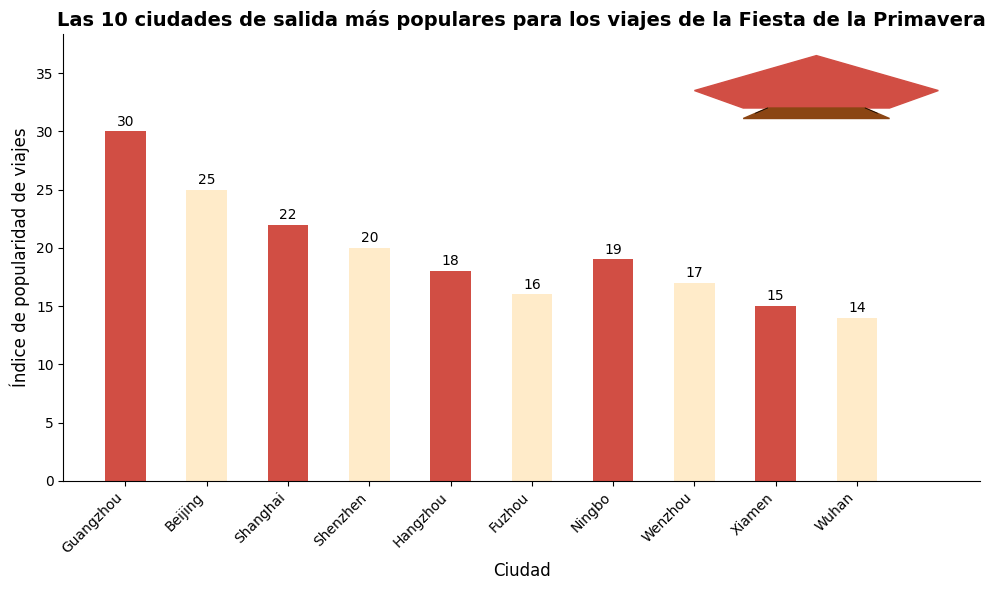

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las ciudades
ciudades = ["Guangzhou", "Beijing", "Shanghai", "Shenzhen", "Hangzhou", "Fuzhou", "Ningbo", "Wenzhou", "Xiamen", "Wuhan"]
# Datos simulados para el gráfico de barras, generalmente mostrando diferencias de altura, se pueden ajustar según la situación real
datos = [30, 25, 22, 20, 18, 16, 19, 17, 15, 14]

x = np.arange(len(ciudades))  # Coordenadas del eje x
ancho = 0.5  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))  # Crear un lienzo y un objeto de eje, establecer el tamaño de la figura
# Dibujar el gráfico de barras, establecer los colores en dos tonos cercanos a la imagen original, los valores rgb se pueden ajustar para acercarse más
barras1 = ax.bar(x[::2], datos[::2], ancho, color=(209/255, 78/255, 68/255))  # Barras de la serie roja
barras2 = ax.bar(x[1::2], datos[1::2], ancho, color=(255/255, 235/255, 201/255))  # Barras de color beige claro

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(ciudades, rotation=45, ha='right', fontsize=10)  # Inclinar 45 grados y alinear a la derecha

# Establecer el título del gráfico
ax.set_title("Las 10 ciudades de salida más populares para los viajes de la Fiesta de la Primavera", fontsize=14, fontweight='bold')

# Agregar etiqueta al eje x
ax.set_xlabel("Ciudad", fontsize=12)
# Agregar etiqueta y unidad al eje y
ax.set_ylabel("Índice de popularidad de viajes", fontsize=12)

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Agregar etiquetas numéricas sobre cada barra
for i, v in enumerate(datos):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)

# Usar métodos de dibujo puros para crear elementos decorativos en lugar de imágenes
from matplotlib.patches import Polygon, Circle

# Crear la forma de un globo aerostático
def crear_globo(ax, x, y, escala=1.0):
    # Cuerpo del globo
    globo = Polygon([
        (x, y+15*escala), (x-5*escala, y+5*escala), (x-3*escala, y), 
        (x+3*escala, y), (x+5*escala, y+5*escala), (x, y+15*escala)
    ], fill=True, color=(209/255, 78/255, 68/255))
    ax.add_patch(globo)
    
    # Canasta
    canasta = Polygon([
        (x-2*escala, y), (x-3*escala, y-3*escala), 
        (x+3*escala, y-3*escala), (x+2*escala, y)
    ], fill=True, color=(139/255, 69/255, 19/255))
    ax.add_patch(canasta)
    
    # Cuerdas
    ax.plot([x-2*escala, x-2.5*escala], [y, y-1.5*escala], 'k-', linewidth=0.5)
    ax.plot([x+2*escala, x+2.5*escala], [y, y-1.5*escala], 'k-', linewidth=0.5)

# Agregar una decoración de globo aerostático en la esquina superior derecha
crear_globo(ax, 8.5, 32, escala=0.3)

plt.tight_layout()  # Ajustar el diseño para garantizar que las etiquetas no se solapen
plt.show()

# 文件: chart_21_5.py

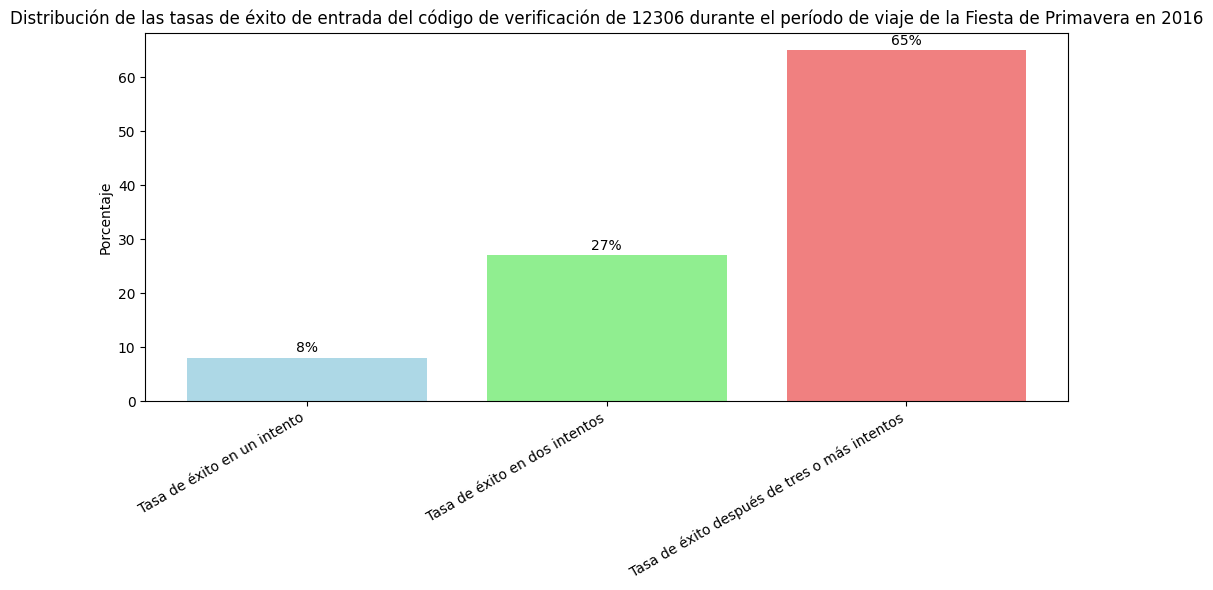

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
etiquetas = ['Tasa de éxito en un intento', 'Tasa de éxito en dos intentos', 'Tasa de éxito después de tres o más intentos']
valores = [8, 27, 65]

# Crear una figura
fig, ax = plt.subplots(figsize=(10, 6))  # Ajustar el ancho del gráfico

# Dibujar un gráfico de barras
ax.bar(etiquetas, valores, color=['lightblue', 'lightgreen', 'lightcoral'])

# Configurar la rotación de las etiquetas del eje x en 30 grados
plt.xticks(rotation=30, ha='right', fontsize=10)  # Inclinar 30 grados y alinear a la derecha

# Agregar etiquetas numéricas
for i, v in enumerate(valores):
    ax.text(i, v + 1, f'{v}%', ha='center')

# Establecer el título y las etiquetas de los ejes (ajustar según sea necesario)
ax.set_ylabel('Porcentaje')
# Agregar un título
ax.set_title('Distribución de las tasas de éxito de entrada del código de verificación de 12306 durante el período de viaje de la Fiesta de Primavera en 2016')

# Mostrar la figura
plt.tight_layout()  # Ajustar el diseño
plt.show()